In [10]:
import numpy as np
import pandas as pd
X = np.linspace(0, 10, 100)
Y = np.sin(X) + 0.3 * np.random.randn(100)
X[:5]

array([0.       , 0.1010101, 0.2020202, 0.3030303, 0.4040404])

$$\{(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), \dots, (x^{(m)}, y^{(m)})\}$$
$$h_\theta(x) = \theta^T x = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$
$$J(\theta) = \frac{1}{2} \sum_{i=1}^{m} w^{(i)} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$
$$w^{(i)} = \exp\left(-\frac{(x - x^{(i)})^T(x - x^{(i)})}{2\tau^2}\right)$$
$$
X \in \mathbb{R}^{m \times n}  \text{：每行是一个 } x^{(i)} \quad \\
y \in \mathbb{R}^{m \times 1}  \text{：标签向量} \qquad \\
W \in \mathbb{R}^{m \times m}  \text{：对角矩阵，} W_{ii} = w^{(i)}
$$
$$J(\theta) = \frac{1}{2} (X\theta - y)^T W (X\theta - y)$$
$$\nabla_\theta J(\theta) = X^T W (X\theta - y) = 0$$
$$\theta = (X^T W X)^{-1} X^T W y$$

#### tau小看重近

In [11]:
def get_weights(query_point, X, tau):
    weights = np.exp(-np.sum((X - query_point)**2, axis=1) / (2 * tau**2))
    return np.diag(weights)

def locally_weight_regression(X, y, tau, query_points):
    y_preds = []
    for q in query_points:
        W = get_weights(q, X, tau)
        if np.linalg.det(X.T @ W @ X) == 0:
            theta = np.linalg.pinv(X.T @ W @ X) @ X.T @ W @ y
        else:
            theta = np.linalg.inv(X.T @ W @ X) @ X.T @ W @ y
        y_pred = q @ theta
        y_preds.append(y_pred)
    return np.array(y_preds)

In [12]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X.reshape(-1, 1))  # (n, 1)

query_points = np.linspace(0, 10, 300).reshape(-1, 1)
query_poly = poly.transform(query_points)

In [13]:
tau = 0.5
y_preds = locally_weight_regression(X_poly, Y, tau, query_poly)

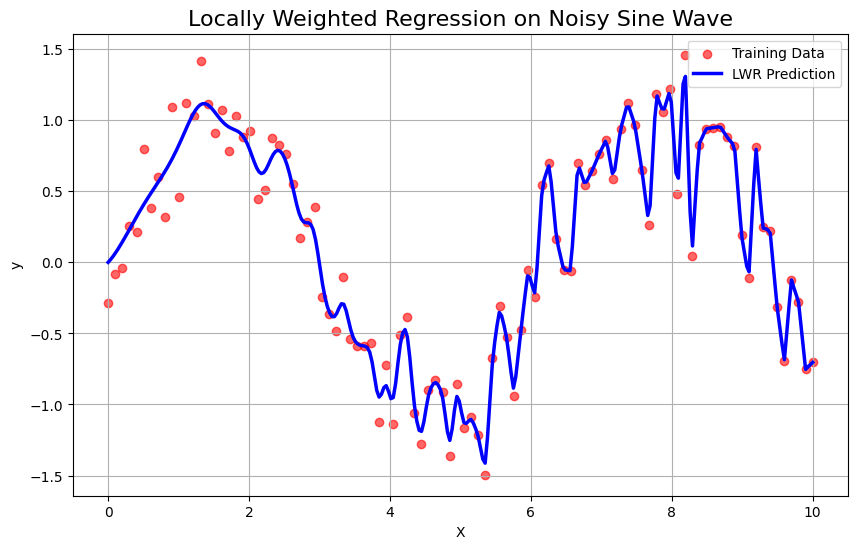

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='red', label='Training Data', alpha=0.6)
plt.plot(query_points, y_preds, color='blue', linewidth=2.5, label='LWR Prediction')
plt.title('Locally Weighted Regression on Noisy Sine Wave', fontsize=16)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

#### 数据量小(<10000)/局部变化明显/需要可解释性强的模型时可用